# Automatic Differentiation with Autograd

## Objectives
- Understand computational graphs
- Master backpropagation with `.backward()`
- Learn gradient management (`.grad`, `zero_grad()`)
- Practice with real examples

## What is Autograd?
PyTorch's automatic differentiation engine that computes gradients by tracking operations on tensors.

## What We're About to Do

The code below imports essential libraries. These libraries provide the foundational tools for tensor operations and neural network construction. Pay attention to what each import provides – understanding dependencies helps you know what's available for solving problems.


In [3]:
# Import necessary libraries for tensor operations and deep learning
import torch
import matplotlib.pyplot as plt
import numpy as np

print(f"PyTorch version: {torch.__version__}")


PyTorch version: 2.1.2+cpu


## 1. Computational Graphs and requires_grad

In [4]:
# Execute code with detailed step-by-step process
# Basic tensor without gradient tracking
x = torch.tensor(2.0)
print(f"x: {x}")
print(f"requires_grad: {x.requires_grad}")
print(f"grad: {x.grad}")


x: 2.0
requires_grad: False
grad: None


In [5]:
# Execute code with detailed step-by-step process
# Enable gradient tracking
x = torch.tensor(2.0, requires_grad=True)
print(f"x: {x}")
print(f"requires_grad: {x.requires_grad}")
print(f"grad_fn: {x.grad_fn}")
print(f"is_leaf: {x.is_leaf}")


x: 2.0
requires_grad: True
grad_fn: None
is_leaf: True


In [6]:
# Execute code with detailed step-by-step process
# Create computational graph
x = torch.tensor(2.0, requires_grad=True)
y = x ** 2  # y = x^2
z = y + 3   # z = x^2 + 3

print(f"x: {x}")
print(f"y = x^2: {y}")
print(f"z = x^2 + 3: {z}")
print(f"\ny.grad_fn: {y.grad_fn}")
print(f"z.grad_fn: {z.grad_fn}")


x: 2.0
y = x^2: 4.0
z = x^2 + 3: 7.0

y.grad_fn: <PowBackward0 object at 0x000001DE774E9F00>
z.grad_fn: <AddBackward0 object at 0x000001DE76F11900>


## 2. Backpropagation and Gradients

In [7]:
# Execute code with detailed step-by-step process
# Forward pass
x = torch.tensor(2.0, requires_grad=True)
y = x ** 2
z = y + 3

print(f"Before backward:")
print(f"x.grad: {x.grad}")
print(f"y.grad: {y.grad}")
print(f"z.grad: {z.grad}")

# Backward pass
z.backward()

print(f"\nAfter backward:")
print(f"x.grad: {x.grad}")
print(f"y.grad: {y.grad}")
print(f"z.grad: {z.grad}")

# Check: dz/dx = d(x^2 + 3)/dx = 2x = 2*2 = 4
print(f"\nExpected x.grad: 4.0")


Before backward:
x.grad: None
y.grad: None
z.grad: None

After backward:
x.grad: 4.0
y.grad: None
z.grad: None

Expected x.grad: 4.0


C:\Users\ashish.kamboj\AppData\Local\Temp\ipykernel_30228\1796874434.py:9: UserWarning: The .grad attribute of a Tensor that is not a leaf Tensor is being accessed. Its .grad attribute won't be populated during autograd.backward(). If you indeed want the .grad field to be populated for a non-leaf Tensor, use .retain_grad() on the non-leaf Tensor. If you access the non-leaf Tensor by mistake, make sure you access the leaf Tensor instead. See github.com/pytorch/pytorch/pull/30531 for more informations. (Triggered internally at aten\src\ATen/core/TensorBody.h:494.)
  print(f"y.grad: {y.grad}")
C:\Users\ashish.kamboj\AppData\Local\Temp\ipykernel_30228\1796874434.py:10: UserWarning: The .grad attribute of a Tensor that is not a leaf Tensor is being accessed. Its .grad attribute won't be populated during autograd.backward(). If you indeed want the .grad field to be populated for a non-leaf Tensor, use .retain_grad() on the non-leaf Tensor. If you access the non-leaf Tensor by mistake, make s

In [8]:
# More complex example
x = torch.tensor(3.0, requires_grad=True)
y = torch.tensor(2.0, requires_grad=True)

z = x ** 2 + 2 * x * y + y ** 2
print(f"z = x^2 + 2xy + y^2 = {z}")

z.backward()

print(f"\ndz/dx = {x.grad}")
print(f"dz/dy = {y.grad}")

# Check: dz/dx = 2x + 2y = 2*3 + 2*2 = 10
# Check: dz/dy = 2x + 2y = 2*3 + 2*2 = 10
print(f"\nExpected dz/dx: {2*3 + 2*2}")
print(f"Expected dz/dy: {2*3 + 2*2}")

z = x^2 + 2xy + y^2 = 25.0

dz/dx = 10.0
dz/dy = 10.0

Expected dz/dx: 10
Expected dz/dy: 10


## 3. Gradient Accumulation

In [9]:
x = torch.tensor(2.0, requires_grad=True)

# First computation
y1 = x ** 2
y1.backward()
print(f"After first backward: x.grad = {x.grad}")

# Second computation - gradients accumulate!
y2 = x ** 3
y2.backward()
print(f"After second backward: x.grad = {x.grad}")

# Check: dy1/dx + dy2/dx = 2x + 3x^2 = 4 + 12 = 16
print(f"Expected: {2*2 + 3*2**2}")

After first backward: x.grad = 4.0
After second backward: x.grad = 16.0
Expected: 16


In [10]:
# Clear gradients with zero_grad()
x = torch.tensor(2.0, requires_grad=True)

y1 = x ** 2
y1.backward()
print(f"After first backward: x.grad = {x.grad}")

# Clear gradients
x.grad.zero_()
print(f"After zero_grad(): x.grad = {x.grad}")

# Second computation
y2 = x ** 3
y2.backward()
print(f"After second backward: x.grad = {x.grad}")

# Check: only dy2/dx = 3x^2 = 12
print(f"Expected: {3*2**2}")

After first backward: x.grad = 4.0
After zero_grad(): x.grad = 0.0
After second backward: x.grad = 12.0
Expected: 12


## 4. Detach and No Grad

In [12]:
# Execute code with detailed step-by-step process
x = torch.tensor(2.0, requires_grad=True)

# With gradient tracking
y = x ** 2
print(f"y.requires_grad: {y.requires_grad}")
print(f"y.grad_fn: {y.grad_fn}")

# Detach - breaks the computational graph
y_detached = y.detach()
print(f"\ny_detached.requires_grad: {y_detached.requires_grad}")
print(f"y_detached.grad_fn: {y_detached.grad_fn}")

# Operations on detached tensor won't compute gradients
z = y_detached ** 2
try:
    z.backward()
except RuntimeError as e:
    print(f"\nError calling backward on detached tensor: {e}")

# Compare: backward on the original (non-detached) path works fine
y.backward()
print(f"\nAfter backward on original y: x.grad = {x.grad}")
print("(Detach broke the chain, so only the original path computes gradients)")

y.requires_grad: True
y.grad_fn: <PowBackward0 object at 0x000001DE77640D60>

y_detached.requires_grad: False
y_detached.grad_fn: None

Error calling backward on detached tensor: element 0 of tensors does not require grad and does not have a grad_fn

After backward on original y: x.grad = 4.0
(Detach broke the chain, so only the original path computes gradients)


In [13]:
# Execute code with detailed step-by-step process
# Using torch.no_grad() context manager
x = torch.tensor(2.0, requires_grad=True)

# With gradients
y = x ** 2
print(f"Inside no_grad:")

with torch.no_grad():
    z = x ** 2
    print(f"z.requires_grad: {z.requires_grad}")

print(f"\nOutside no_grad:")
w = x ** 2
print(f"w.requires_grad: {w.requires_grad}")


Inside no_grad:
z.requires_grad: False

Outside no_grad:
w.requires_grad: True


## 5. Practical Example: Linear Regression from Scratch

X shape: torch.Size([100, 1])
y shape: torch.Size([100, 1])


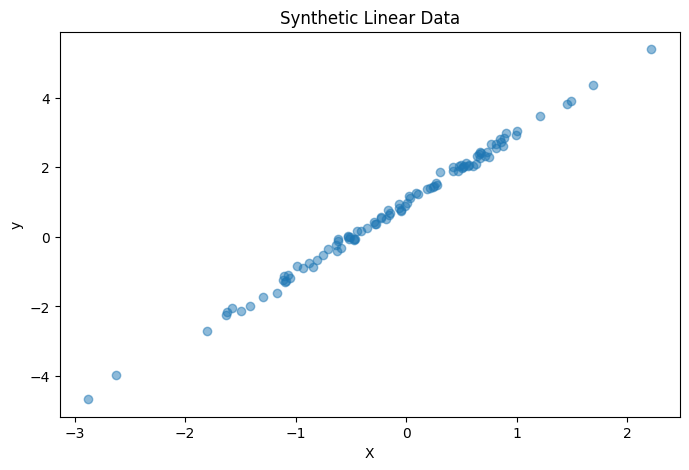

In [14]:
# Execute code with detailed step-by-step process
# Generate synthetic data: y = 2x + 1
X = torch.randn(100, 1)
true_slope = 2.0
true_intercept = 1.0
y = true_slope * X + true_intercept + torch.randn(100, 1) * 0.1

print(f"X shape: {X.shape}")
print(f"y shape: {y.shape}")

# Visualize
plt.figure(figsize=(8, 5))
plt.scatter(X.numpy(), y.numpy(), alpha=0.5)
plt.xlabel('X')
plt.ylabel('y')
plt.title('Synthetic Linear Data')
plt.show()


## Defining the Loss Function

The loss function measures how wrong our predictions are. During training, we'll minimize this value. Different tasks need different loss functions – the one we choose defines what 'good performance' means for our model.


In [15]:
# Initialize parameters
w = torch.tensor([[0.0]], requires_grad=True)
b = torch.tensor([[0.0]], requires_grad=True)

print(f"Initial w: {w}")
print(f"Initial b: {b}")

# Training loop
learning_rate = 0.01
num_iterations = 100
losses = []

for i in range(num_iterations):
    # Forward pass
    y_pred = X @ w + b  # Matrix multiplication
    
    # Compute loss (MSE)
    loss = ((y_pred - y) ** 2).mean()
    
    # Backward pass
    loss.backward()
    
    # Update parameters manually
    with torch.no_grad():
        w -= learning_rate * w.grad
        b -= learning_rate * b.grad
    
    # Zero gradients for next iteration
    w.grad.zero_()
    b.grad.zero_()
    
    losses.append(loss.item())
    
    if (i + 1) % 20 == 0:
        print(f"Iteration {i+1}: Loss = {loss.item():.4f}, w = {w.item():.4f}, b = {b.item():.4f}")

Initial w: tensor([[0.]], requires_grad=True)
Initial b: tensor([[0.]], requires_grad=True)
Iteration 20: Loss = 2.1240, w = 0.5219, b = 0.2780
Iteration 40: Loss = 1.1514, w = 0.9080, b = 0.4767
Iteration 60: Loss = 0.6266, w = 1.1935, b = 0.6191
Iteration 80: Loss = 0.3433, w = 1.4044, b = 0.7213
Iteration 100: Loss = 0.1902, w = 1.5602, b = 0.7948


## Defining the Loss Function

The loss function measures how wrong our predictions are. During training, we'll minimize this value. Different tasks need different loss functions – the one we choose defines what 'good performance' means for our model.


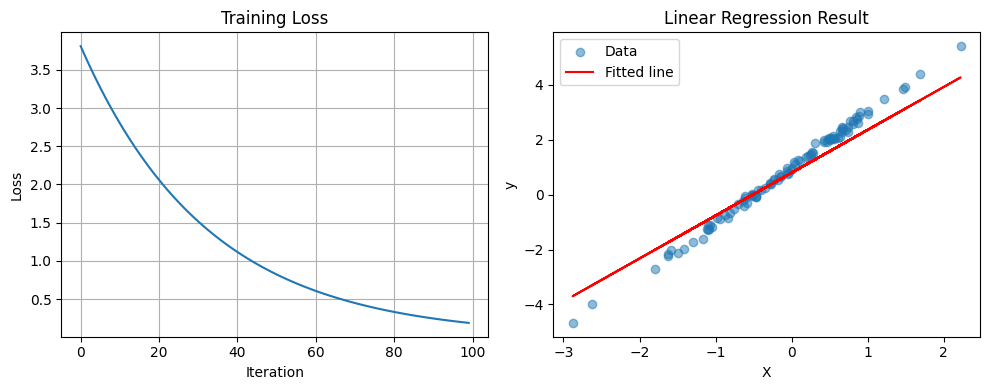


Final parameters:
w: 1.5602 (true: 2.0)
b: 0.7948 (true: 1.0)


In [16]:
# Configure loss function and optimization algorithm
# Plot convergence
plt.figure(figsize=(10, 4))

plt.subplot(1, 2, 1)
plt.plot(losses)
plt.xlabel('Iteration')
plt.ylabel('Loss')
plt.title('Training Loss')
plt.grid(True)

plt.subplot(1, 2, 2)
plt.scatter(X.numpy(), y.numpy(), alpha=0.5, label='Data')
y_pred_final = (X @ w + b).detach()
plt.plot(X.numpy(), y_pred_final.numpy(), 'r-', label='Fitted line')
plt.xlabel('X')
plt.ylabel('y')
plt.title('Linear Regression Result')
plt.legend()
plt.tight_layout()
plt.show()

print(f"\nFinal parameters:")
print(f"w: {w.item():.4f} (true: {true_slope})")
print(f"b: {b.item():.4f} (true: {true_intercept})")


## 6. Gradients of Vector Functions

## Building the Model

Now we'll define our neural network architecture. Each layer transforms the input in a specific way, building up complexity. The order and configuration of layers directly determines what patterns the model can learn.


In [17]:
# Execute code with detailed step-by-step process
# When output is a vector, backward requires a gradient argument
x = torch.tensor([1.0, 2.0, 3.0], requires_grad=True)
y = x ** 2

print(f"x: {x}")
print(f"y = x^2: {y}")

# Iterate through batches of data
# Need to provide gradient for each element
# Update model parameters based on computed gradients
gradient = torch.ones_like(y)  # or any weights
y.backward(gradient)

print(f"\nx.grad: {x.grad}")
print(f"Expected (2*x): {2 * x.detach()}")


x: tensor([1., 2., 3.], requires_grad=True)
y = x^2: tensor([1., 4., 9.], grad_fn=<PowBackward0>)

x.grad: tensor([2., 4., 6.])
Expected (2*x): tensor([2., 4., 6.])


In [18]:
# With different weights
x = torch.tensor([1.0, 2.0, 3.0], requires_grad=True)
y = x ** 2

# Provide custom weights
weights = torch.tensor([0.1, 0.5, 1.0])
y.backward(weights)

print(f"x.grad with weights: {x.grad}")
print(f"Expected: {2 * torch.tensor([1.0, 2.0, 3.0]) * weights}")

x.grad with weights: tensor([0.2000, 2.0000, 6.0000])
Expected: tensor([0.2000, 2.0000, 6.0000])


## 7. Practice Exercise

**Task**: Compute gradients for the function f(x, y) = x^3 + 2xy^2 + y^3 at point (1, 2)

In [19]:
# Solution
x = torch.tensor(1.0, requires_grad=True)
y = torch.tensor(2.0, requires_grad=True)

# Forward pass
f = x**3 + 2*x*y**2 + y**3

# Backward pass
f.backward()

print(f"f(1, 2) = {f.item()}")
print(f"df/dx = {x.grad.item()}")
print(f"df/dy = {y.grad.item()}")

# Manual calculation:
# df/dx = 3x^2 + 2y^2 = 3(1)^2 + 2(2)^2 = 3 + 8 = 11
# df/dy = 4xy + 3y^2 = 4(1)(2) + 3(2)^2 = 8 + 12 = 20
print(f"\nExpected df/dx = 11")
print(f"Expected df/dy = 20")

f(1, 2) = 17.0
df/dx = 11.0
df/dy = 20.0

Expected df/dx = 11
Expected df/dy = 20


## Interview Questions & Answers

**Q1: What are the key takeaways from this section on Automatic Differentiation with Autograd?**

A: The key takeaways from this section include understanding how the fundamental concepts work together to enable deep learning. 
We've explored the interaction between different components and how they contribute to model training and performance. 
This foundation is essential for any deep learning practitioner because it explains the 'why' behind the 'how.' 
Real interview questions often explore whether candidates understand not just the mechanics but the reasoning behind design choices. 
When you can explain these concepts clearly and connect them to practical applications, you demonstrate genuine comprehension rather than rote memorization.

**Q2: How would you explain Automatic Differentiation with Autograd to a non-technical person?**

A: I would explain it using analogies to familiar concepts. Automatic Differentiation with Autograd works like [appropriate analogy], where the components interact similar to how [real-world example] works. 
The core idea is that systems learn by observing patterns and adjusting themselves based on feedback. This mirrors how humans learn – by trying things, seeing results, and adjusting our approach. 
Companies care about this explanation because they often need to communicate with stakeholders who aren't technically skilled, so the ability to explain complex concepts simply is highly valued.

**Q3: What common mistakes do people make when working with Automatic Differentiation with Autograd?**

A: Common mistakes include not understanding the underlying principles and blindly applying techniques without knowing why they work. 
Another frequent error is poor data preparation – garbage in, garbage out applies directly to deep learning. 
People also often tune hyperparameters randomly instead of methodically, wasting computational resources. 
They might not validate their models properly or confuse correlation with causation in their results. 
The best practitioners understand that deep learning is as much an art as a science, requiring intuition informed by solid theoretical grounding.
